## Week-3
### Notebook doing Exploratory Data Analysis (EDA) for the Bike rental data, along with Weather and Holidays Data

In [85]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [86]:
import sys
from pathlib import Path

# go to project root (parent of week-3)
project_root = Path.cwd().resolve().parent

# add src to Python path
sys.path.append(str(project_root / "src"))

In [87]:
from bike_rental.defs.resources.project_config import ProjectConfig

cfgs = ProjectConfig()
cfgs.curated_path

'data/raw/curated_rental_dataset.csv'

In [88]:
data = pd.read_csv(f"../{cfgs.curated_path}")
data["datetime"] = pd.to_datetime(data["datetime"])
data = data.sort_values("datetime")

In [89]:
data.head()

,location_id,datetime,count_rentals,count_pickups,dayofweek,year,month,day,quarter,hour,...,total_count,temperature_c,perceived_temperature_c,humidity,windspeed_kmh,conditions_clear,conditions_clouds,conditions_heavy_rain,conditions_light_rain,is_holiday
0,2,2011-01-01,0.0,1.0,5,2011,1,1,1,0,...,1.0,3.3,3.0,81.0,0.0,1.0,0.0,0.0,0.0,0
9,16,2011-01-01,1.0,0.0,5,2011,1,1,1,0,...,1.0,3.3,3.0,81.0,0.0,1.0,0.0,0.0,0.0,0
8,14,2011-01-01,0.0,1.0,5,2011,1,1,1,0,...,1.0,3.3,3.0,81.0,0.0,1.0,0.0,0.0,0.0,0
7,13,2011-01-01,2.0,0.0,5,2011,1,1,1,0,...,2.0,3.3,3.0,81.0,0.0,1.0,0.0,0.0,0.0,0
6,12,2011-01-01,2.0,0.0,5,2011,1,1,1,0,...,2.0,3.3,3.0,81.0,0.0,1.0,0.0,0.0,0.0,0


#### All the columns we have in the current dataset, we need to remove the count_rentals and count_pickups as we only want to predict per day bike estimation

In [90]:
data.columns

Index(['location_id', 'datetime', 'count_rentals', 'count_pickups',
       'dayofweek', 'year', 'month', 'day', 'quarter', 'hour',
       'is_month_start', 'is_month_end', 'is_weekend', 'hour_sin', 'hour_cos',
       'total_count', 'temperature_c', 'perceived_temperature_c', 'humidity',
       'windspeed_kmh', 'conditions_clear', 'conditions_clouds',
       'conditions_heavy_rain', 'conditions_light_rain', 'is_holiday'],
      dtype='str')

In [91]:
# Dropping the Not Needed Columns
data = data.drop(columns=["count_rentals", "count_pickups"])
data.columns

Index(['location_id', 'datetime', 'dayofweek', 'year', 'month', 'day',
       'quarter', 'hour', 'is_month_start', 'is_month_end', 'is_weekend',
       'hour_sin', 'hour_cos', 'total_count', 'temperature_c',
       'perceived_temperature_c', 'humidity', 'windspeed_kmh',
       'conditions_clear', 'conditions_clouds', 'conditions_heavy_rain',
       'conditions_light_rain', 'is_holiday'],
      dtype='str')

#### After Checking All the data, such as 

In [92]:
data.isnull().sum()

location_id                   0
datetime                      0
dayofweek                     0
year                          0
month                         0
day                           0
quarter                       0
hour                          0
is_month_start                0
is_month_end                  0
is_weekend                    0
hour_sin                      0
hour_cos                      0
total_count                   0
temperature_c              3465
perceived_temperature_c    3465
humidity                   3465
windspeed_kmh              3465
conditions_clear           3465
conditions_clouds          3465
conditions_heavy_rain      3465
conditions_light_rain      3465
is_holiday                    0
dtype: int64

- We can see there are empty values specially in weather related datasets

In [93]:
data = data.dropna()

In [94]:
data.info()

<class 'pandas.DataFrame'>
Index: 364947 entries, 0 to 368411
Data columns (total 23 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   location_id              364947 non-null  int64         
 1   datetime                 364947 non-null  datetime64[us]
 2   dayofweek                364947 non-null  int64         
 3   year                     364947 non-null  int64         
 4   month                    364947 non-null  int64         
 5   day                      364947 non-null  int64         
 6   quarter                  364947 non-null  int64         
 7   hour                     364947 non-null  int64         
 8   is_month_start           364947 non-null  int64         
 9   is_month_end             364947 non-null  int64         
 10  is_weekend               364947 non-null  int64         
 11  hour_sin                 364947 non-null  float64       
 12  hour_cos                 364947 

In [95]:
data.duplicated().sum()

np.int64(0)

In [96]:
data.describe()

,location_id,datetime,dayofweek,year,month,day,quarter,hour,is_month_start,is_month_end,...,total_count,temperature_c,perceived_temperature_c,humidity,windspeed_kmh,conditions_clear,conditions_clouds,conditions_heavy_rain,conditions_light_rain,is_holiday
count,364947.000000,364947,364947.000000,364947.000000,364947.000000,364947.000000,364947.000000,364947.000000,364947.000000,364947.000000,...,364947.000000,364947.000000,364947.000000,364947.000000,364947.000000,364947.000000,364947.000000,364947.000000,364947.000000,364947.000000
mean,10.000005,2012-01-02 15:52:58.403439,3.011413,2011.502572,6.537897,15.683729,2.512088,11.547005,0.033060,0.032966,...,9.022348,15.354595,15.401530,62.722371,12.736603,0.656701,0.261474,0.000173,0.081653,0.028771
min,0.000000,2011-01-01 00:00:00,0.000000,2011.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,-7.100000,-16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.000000,2011-07-04 23:00:00,1.000000,2011.000000,4.000000,8.000000,2.000000,6.000000,0.000000,0.000000,...,2.000000,8.000000,6.000000,48.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,10.000000,2012-01-02 21:00:00,3.000000,2012.000000,7.000000,16.000000,3.000000,12.000000,0.000000,0.000000,...,6.000000,15.500000,16.000000,63.000000,13.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,15.000000,2012-07-02 07:00:00,5.000000,2012.000000,10.000000,23.000000,4.000000,18.000000,0.000000,0.000000,...,13.000000,23.000000,25.000000,78.000000,17.000000,1.000000,1.000000,0.000000,0.000000,0.000000
max,20.000000,2012-12-31 23:00:00,6.000000,2012.000000,12.000000,31.000000,4.000000,23.000000,1.000000,1.000000,...,64.000000,39.000000,50.000000,100.000000,57.000000,1.000000,1.000000,1.000000,1.000000,1.000000
std,6.055275,NaN,2.001904,0.499994,3.438592,8.788868,1.114063,6.914013,0.178792,0.178549,...,9.122896,9.049517,11.341505,19.292534,8.196526,0.474811,0.439438,0.013138,0.273836,0.167163


<Axes: >

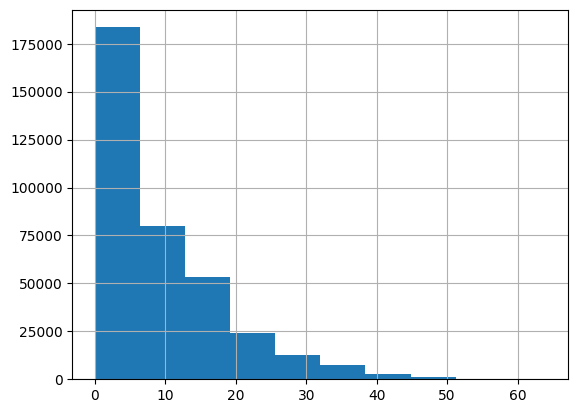

In [97]:
data["total_count"].hist(bins=10)

<Axes: >

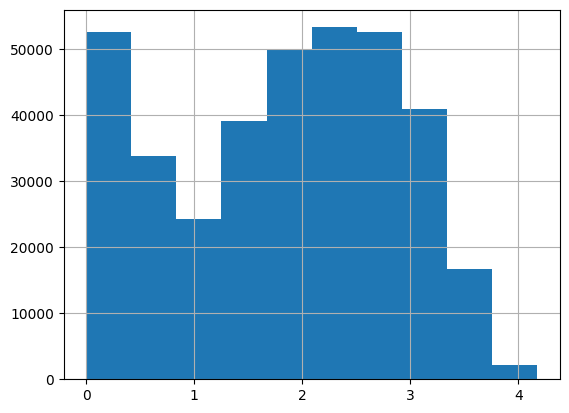

In [98]:
data["log_total_count"] = np.log1p(data["total_count"])
data["log_total_count"].hist(bins=10)

#### We can see around same time of the Year in both year it Increases and Decreases 

<Axes: xlabel='datetime'>

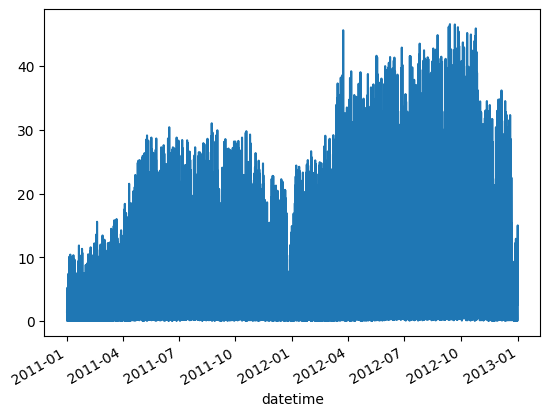

In [99]:
data.groupby("datetime")["total_count"].mean().plot()

<Axes: xlabel='datetime'>

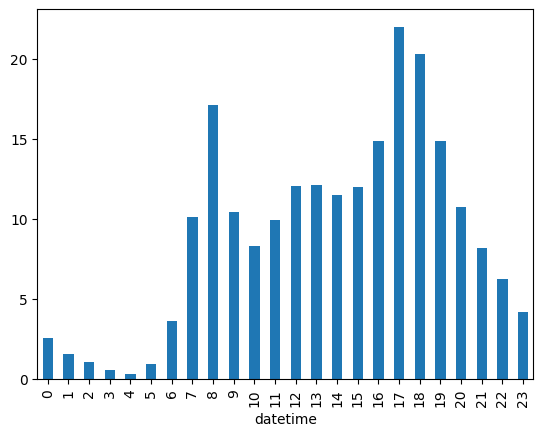

In [100]:
data.groupby(data["datetime"].dt.hour)["total_count"].mean().plot(kind="bar")

In [101]:
data.groupby("weekday")["total_count"].mean()

KeyError: 'weekday'

In [ ]:
data.groupby("month")["total_count"].mean()

month
1      4.497917
2      5.374525
3      7.400511
4      8.917189
5     10.614631
6     11.453108
7     11.039042
8     11.337982
9     11.465388
10    10.578977
11     8.444544
12     6.776789
Name: total_count, dtype: float64

- We can see above mainly in summer there is higher demand overall compare to Year End and Start

<Axes: xlabel='temperature_c', ylabel='total_count'>

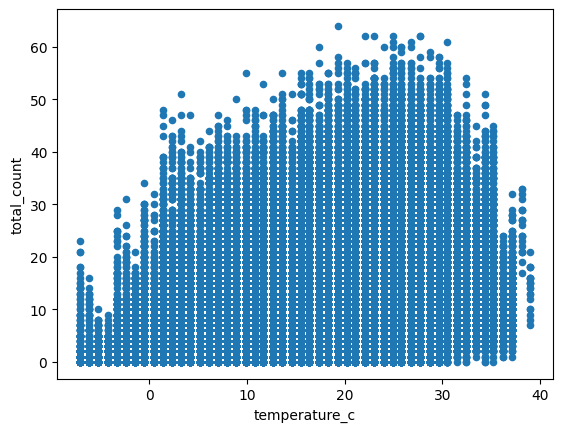

In [ ]:
data.plot.scatter(x="temperature_c", y="total_count")

- If temperature is not so high and not so low, and good like between 15-35 there is higher demand overall

<Axes: xlabel='humidity'>

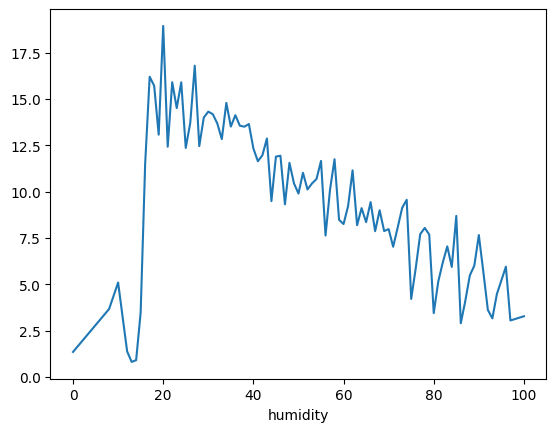

In [ ]:
data.groupby("humidity")["total_count"].mean().plot()

In [ ]:
data.groupby(
    ["conditions_clear", "conditions_light_rain", "conditions_heavy_rain"]
)["total_count"].mean()

conditions_clear  conditions_light_rain  conditions_heavy_rain
0.0               0.0                    0.0                      8.341214
                                         1.0                      3.539683
                  1.0                    0.0                      5.313299
1.0               0.0                    0.0                      9.756168
Name: total_count, dtype: float64

- We can see how demand decreases as the chances of raining increases
- clear > cloudy > light rain > heavy rain

In [ ]:
data.groupby("is_holiday")["total_count"].mean()

is_holiday
0    9.068335
1    7.470000
Name: total_count, dtype: float64

- Due to holiday, there is slightly less demand compared to More holiday

<Axes: xlabel='temperature_c', ylabel='humidity'>

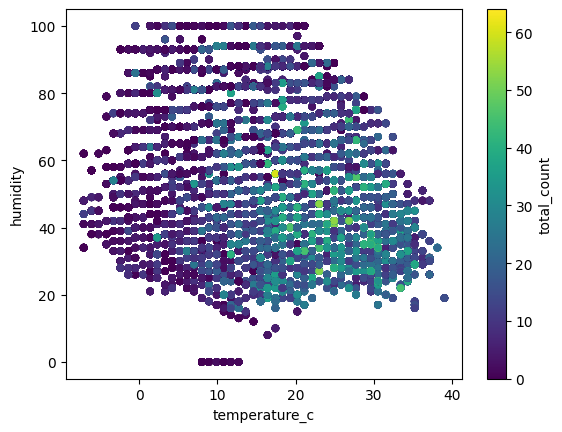

In [ ]:
data.plot.scatter(x="temperature_c", y="humidity", c="total_count")

- We can see when temperature is good and Humidity is also not so high, There is high demand compared to High Humidity and High/Low Temperature

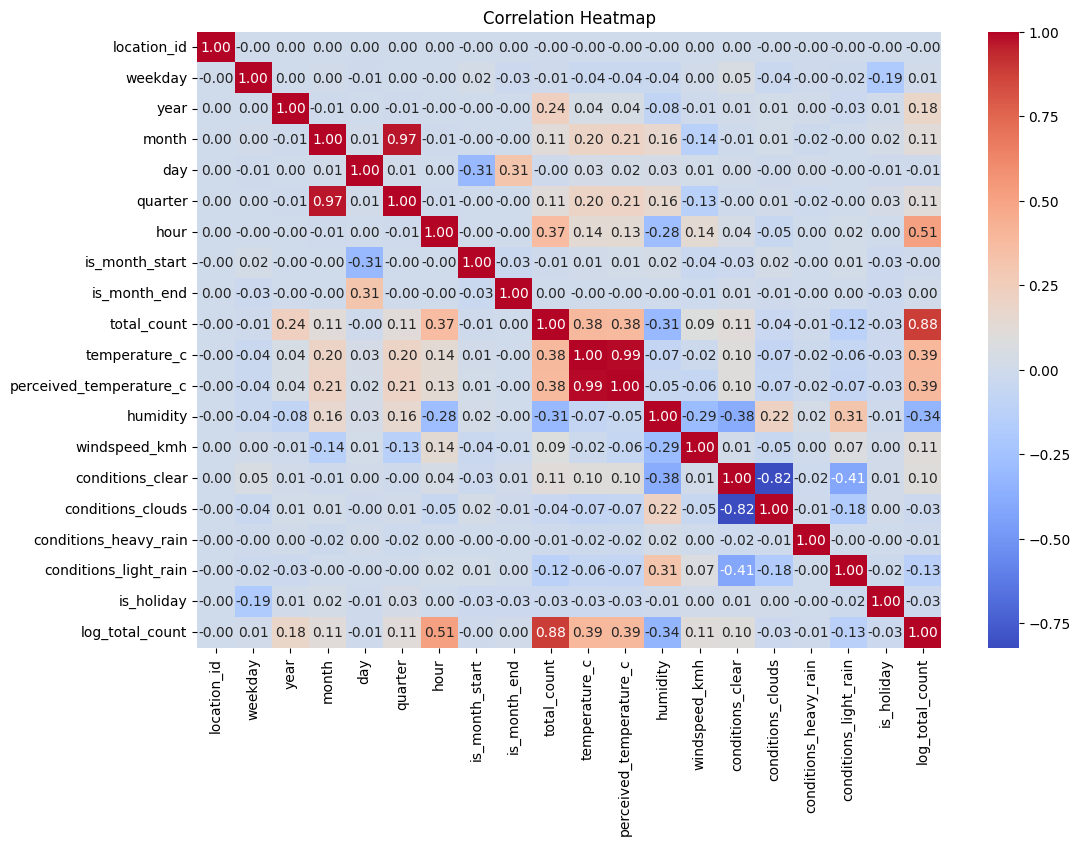

In [ ]:
corr = data.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

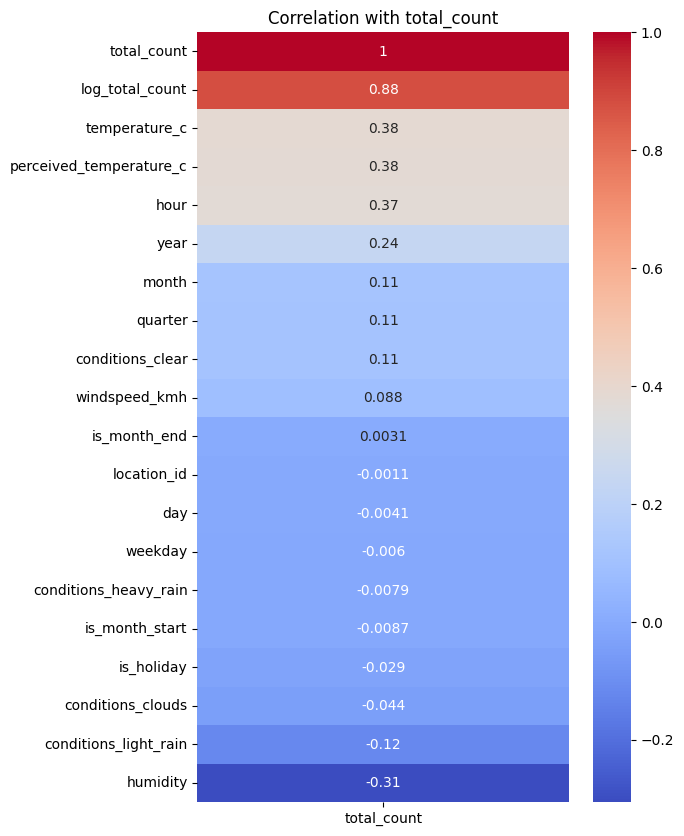

In [ ]:
target_corr = data.corr(numeric_only=True)[["total_count"]].sort_values(
    by="total_count", ascending=False
)

plt.figure(figsize=(6, 10))
sns.heatmap(target_corr, annot=True, cmap="coolwarm")
plt.title("Correlation with total_count")
plt.show()

#### Let"s see how many Unique Location we have in the City

In [ ]:
print(data.location_id.unique())
print(len(list(data["location_id"].unique())))

[ 2 16 14 13 12 18  9  5  4  3 11 20 19 17 15  0  8  7  6  1 10]
21


- We can see that we have 21 Unique Locations in one city, and suppose if some company will do hourly prediction and suppose put the remaining bike there, it is not going to add much of business value, as revenue can easily end up in this operations of hourly moving here and there.
- So, it is better we predict on daily basis, and put the amount of bikes at the location if needed, or total bikes at the city, which is much better compared to hourly prediction


### Now Let"s first Set the Baseline model for Out regression task to predict the Bike Needed Next Day


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
data.columns

Index(['location_id', 'datetime', 'weekday', 'year', 'month', 'day', 'quarter',
       'hour', 'is_month_start', 'is_month_end', 'total_count',
       'temperature_c', 'perceived_temperature_c', 'humidity', 'windspeed_kmh',
       'conditions_clear', 'conditions_clouds', 'conditions_heavy_rain',
       'conditions_light_rain', 'is_holiday', 'log_total_count'],
      dtype='str')

#### I am planning to Use Naive Forecasting method as Our baseline and Planning to Predict the Bike needed next day, as It makes no sense for a business to running at Multiple location every hour and Fulfill the predicted Bike at every place, so it makes more sense to Use daily prediction for a location.
 - A naive forecast is a simple time-series forecasting technique where the predicted value for any future period is assumed to be exactly equal to the most recent actual value. It uses the "copy-paste" method, meaning tomorrow’s forecast simply copies today's observation. 

#### In the step Below what has been done
- Take only the datetime and Total Count columns from dataset\
- Add date column using the datetime column
- Remove the datetime column
- Group by date to come up with daily count of bikes needed
- Shift the value by 1 row and use the today's bike count as next day's prediction - Naive MAE
- Shift the value by 7 row and use the last week same day value as prediction value - seasonal 7 day NAIVE
- Remove the null value which will be the first value, as we do not have data for day before 01.01.2011
- Reset index and see the output

In [ ]:
daily_df = data[["datetime", "total_count"]].copy()
daily_df["date"] = pd.to_datetime(daily_df["datetime"]).dt.date
daily_df = daily_df.groupby("date")["total_count"].sum().reset_index()
daily_df.head(10)

,date,total_count
0,2011-01-01,985.0
1,2011-01-02,801.0
2,2011-01-03,1349.0
3,2011-01-04,1562.0
4,2011-01-05,1600.0
5,2011-01-06,1606.0
6,2011-01-07,1510.0
7,2011-01-08,959.0
8,2011-01-09,822.0
9,2011-01-10,1321.0


In [ ]:
# --- City-level daily baseline daily ---
daily_df = data[["datetime", "total_count"]].copy()
daily_df["date"] = pd.to_datetime(daily_df["datetime"].dt.date)
daily_df = daily_df.groupby("date")["total_count"].sum().reset_index()
daily_df = daily_df.sort_values("date").reset_index(drop=True)
daily_df["naive_pred"] = daily_df["total_count"].shift(1)
daily_df["seasonal_pred_7"] = daily_df["total_count"].shift(7)
daily_df["pred_7day_avg"] = (
    daily_df["total_count"].shift(1).rolling(window=7).mean()
)
daily_df.head(10)

,date,total_count,naive_pred,seasonal_pred_7,pred_7day_avg
0,2011-01-01,985.0,NaN,NaN,NaN
1,2011-01-02,801.0,985.0,NaN,NaN
2,2011-01-03,1349.0,801.0,NaN,NaN
3,2011-01-04,1562.0,1349.0,NaN,NaN
4,2011-01-05,1600.0,1562.0,NaN,NaN
5,2011-01-06,1606.0,1600.0,NaN,NaN
6,2011-01-07,1510.0,1606.0,NaN,NaN
7,2011-01-08,959.0,1510.0,985.0,1344.714286
8,2011-01-09,822.0,959.0,801.0,1341.000000
9,2011-01-10,1321.0,822.0,1349.0,1344.000000


In [ ]:
# Time-based holdout (last 30 days)
holdout_days = 180
holdout_start = daily_df["date"].max() - pd.Timedelta(days=holdout_days)
print(f"Holdout start date: {holdout_start.date()}")
train_daily = daily_df[daily_df["date"] < holdout_start].copy()
test_daily = daily_df[daily_df["date"] >= holdout_start].copy()
train_daily.shape, test_daily.shape

Holdout start date: 2012-07-04


((550, 5), (181, 5))

In [ ]:
train_daily.head(10)

,date,total_count,naive_pred,seasonal_pred_7,pred_7day_avg
0,2011-01-01,985.0,NaN,NaN,NaN
1,2011-01-02,801.0,985.0,NaN,NaN
2,2011-01-03,1349.0,801.0,NaN,NaN
3,2011-01-04,1562.0,1349.0,NaN,NaN
4,2011-01-05,1600.0,1562.0,NaN,NaN
5,2011-01-06,1606.0,1600.0,NaN,NaN
6,2011-01-07,1510.0,1606.0,NaN,NaN
7,2011-01-08,959.0,1510.0,985.0,1344.714286
8,2011-01-09,822.0,959.0,801.0,1341.000000
9,2011-01-10,1321.0,822.0,1349.0,1344.000000


In [ ]:
test_daily.head(10)

,date,total_count,naive_pred,seasonal_pred_7,pred_7day_avg
550,2012-07-04,7403.0,6660.0,7335.0,6254.571429
551,2012-07-05,6241.0,7403.0,6879.0,6264.285714
552,2012-07-06,6207.0,6241.0,5463.0,6173.142857
553,2012-07-07,4840.0,6207.0,5687.0,6279.428571
554,2012-07-08,4672.0,4840.0,5531.0,6158.428571
555,2012-07-09,6569.0,4672.0,6227.0,6035.714286
556,2012-07-10,6290.0,6569.0,6660.0,6084.571429
557,2012-07-11,7264.0,6290.0,7403.0,6031.714286
558,2012-07-12,7446.0,7264.0,6241.0,6011.857143
559,2012-07-13,7499.0,7446.0,6207.0,6184.000000


In [ ]:
# Evaluate naive (yesterday) on holdout
test_naive = test_daily.dropna(subset=["naive_pred"])
mae_naive = mean_absolute_error(
    test_naive["total_count"], test_naive["naive_pred"]
)
rmse_naive = np.sqrt(
    mean_squared_error(test_naive["total_count"], test_naive["naive_pred"])
)

# Evaluate seasonal (lag-7) on holdout
test_seasonal = test_daily.dropna(subset=["seasonal_pred_7"])
mae_seasonal = mean_absolute_error(
    test_seasonal["total_count"], test_seasonal["seasonal_pred_7"]
)
rmse_seasonal = np.sqrt(
    mean_squared_error(
        test_seasonal["total_count"], test_seasonal["seasonal_pred_7"]
    )
)

# Evaluate 7-day average on holdout
eval_df = test_daily.dropna(subset=["pred_7day_avg"]).copy()

mae_7day = mean_absolute_error(eval_df["total_count"], eval_df["pred_7day_avg"])
rmse_7day = np.sqrt(
    mean_squared_error(eval_df["total_count"], eval_df["pred_7day_avg"])
)

print(f"City-level holdout (last {holdout_days} days):")
print(f"  Holdout period: {holdout_start.date()} to {test_daily['date'].max()}")
print(f"  Naive MAE: {mae_naive:.2f}, RMSE: {rmse_naive:.2f}")
print(f"  Seasonal-7 MAE: {mae_seasonal:.2f}, RMSE: {rmse_seasonal:.2f}")
print(f"  7-Day Average MAE: {mae_7day:.2f}, RMSE: {rmse_7day:.2f}")

City-level holdout (last 180 days):
  Holdout period: 2012-07-04 to 2012-12-31 00:00:00
  Naive MAE: 846.90, RMSE: 1227.47
  Seasonal-7 MAE: 1133.63, RMSE: 1657.40
  7-Day Average MAE: 877.05, RMSE: 1263.48



- We can see above just using the simple data manipulation and statistical techniques like 7 day moving average and naive forecasting, we can already have good baseline to start with

| Model            | MAE     | RMSE    |
|-----------------|---------|---------|
| Naive           | 846.90  | 1227.47 |
| Seasonal-7      | 1133.63 | 1657.40 |
| 7-Day Average   | 877.05  | 1263.48 |

### Now Let's use more data we have and try to add the location into play and see what changes

- Almost all the steps we did for the data without location is being repeated here
- Only group by on location based data is extra 

In [ ]:
# --- Location-level daily baseline ---
loc_daily = data[["datetime", "location_id", "total_count"]].copy()
loc_daily["date"] = pd.to_datetime(loc_daily["datetime"].dt.date)
loc_daily = (
    loc_daily.groupby(["location_id", "date"])["total_count"]
    .sum()
    .reset_index()
)
loc_daily = loc_daily.sort_values(["location_id", "date"]).reset_index(
    drop=True
)
loc_daily["naive_pred"] = loc_daily.groupby("location_id")["total_count"].shift(
    1
)
loc_daily["seasonal_pred_7"] = loc_daily.groupby("location_id")[
    "total_count"
].shift(7)
loc_daily["pred_7day_avg"] = loc_daily.groupby("location_id")[
    "total_count"
].transform(lambda s: s.shift(1).rolling(window=7).mean())
loc_daily.head(10)

,location_id,date,total_count,naive_pred,seasonal_pred_7,pred_7day_avg
0,0,2011-01-01,44.0,NaN,NaN,NaN
1,0,2011-01-02,46.0,44.0,NaN,NaN
2,0,2011-01-03,64.0,46.0,NaN,NaN
3,0,2011-01-04,64.0,64.0,NaN,NaN
4,0,2011-01-05,81.0,64.0,NaN,NaN
5,0,2011-01-06,67.0,81.0,NaN,NaN
6,0,2011-01-07,71.0,67.0,NaN,NaN
7,0,2011-01-08,38.0,71.0,44.0,62.428571
8,0,2011-01-09,33.0,38.0,46.0,61.571429
9,0,2011-01-10,68.0,33.0,64.0,59.714286


In [ ]:
def loc_metrics(df, pred_col):
    """Calculate MAE and RMSE for location-level predictions."""
    df = df.dropna(subset=[pred_col])

    y_true = df["total_count"].values
    y_pred = df[pred_col].values

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    return mae, rmse


# Use same holdout_start (calendar-aligned) for location-level eval
loc_test = loc_daily[loc_daily["date"] >= holdout_start].copy()

naive_loc_metrics = loc_metrics(loc_test, "naive_pred")
seasonal_loc_metrics = loc_metrics(loc_test, "seasonal_pred_7")
dayavg_loc_metrics = loc_metrics(loc_test, "pred_7day_avg")

print(f"Location-level holdout (last {holdout_days} days):")
print(
    f"  Naive MAE: {naive_loc_metrics[0]:.2f},\
       RMSE: {naive_loc_metrics[1]:.2f}"
)
print(
    f"  Seasonal-7 MAE: {seasonal_loc_metrics[0]:.2f},\
       RMSE: {seasonal_loc_metrics[1]:.2f}"
)
print(
    f"  7-Day Average MAE: {dayavg_loc_metrics[0]:.2f},\
       RMSE: {dayavg_loc_metrics[1]:.2f}"
)

Location-level holdout (last 180 days):
  Naive MAE: 45.97,       RMSE: 63.02
  Seasonal-7 MAE: 58.74,       RMSE: 82.36
  7-Day Average MAE: 44.72,       RMSE: 62.73


- We can see that our model in with location based data is baseline model we can see by using simple data transformation and averaging using the last 7 days values
- Score is as follows:

| Model           | MAE   | RMSE  |
|----------------|-------|-------|
| Naive          | 45.97 | 63.02 |
| Seasonal-7     | 58.74 | 82.36 |
| 7-Day Average  | 44.72 | 62.73 |

### Now Let's try with Removing location and Try to Do hourly Prediction

In [ ]:
# --- hourly baseline ---
hourly_daily = (
    data.groupby("datetime", as_index=False)["total_count"]
    .sum()
    .sort_values("datetime")
    .reset_index(drop=True)
)

hourly_daily["naive_pred"] = hourly_daily["total_count"].shift(1)
hourly_daily["seasonal_pred_24hr"] = hourly_daily["total_count"].shift(24)
hourly_daily["pred_24hour_avg"] = (
    hourly_daily["total_count"].shift(1).rolling(24).mean()
)
hourly_daily.head(10)

,datetime,total_count,naive_pred,seasonal_pred_24hr,pred_24hour_avg
0,2011-01-01 00:00:00,16.0,NaN,NaN,NaN
1,2011-01-01 01:00:00,40.0,16.0,NaN,NaN
2,2011-01-01 02:00:00,32.0,40.0,NaN,NaN
3,2011-01-01 03:00:00,13.0,32.0,NaN,NaN
4,2011-01-01 04:00:00,1.0,13.0,NaN,NaN
5,2011-01-01 05:00:00,1.0,1.0,NaN,NaN
6,2011-01-01 06:00:00,2.0,1.0,NaN,NaN
7,2011-01-01 07:00:00,3.0,2.0,NaN,NaN
8,2011-01-01 08:00:00,8.0,3.0,NaN,NaN
9,2011-01-01 09:00:00,14.0,8.0,NaN,NaN


In [ ]:
hourly_daily.isna().sum()

datetime               0
total_count            0
naive_pred             1
seasonal_pred_24hr    24
pred_24hour_avg       24
dtype: int64

In [ ]:
hourly_daily.shape

(17379, 5)

In [ ]:
hourly_daily.dropna(inplace=True)

In [ ]:
# Use same holdout_start (calendar-aligned) for hourly-level eval
hourly_daily = hourly_daily.sort_values("datetime").reset_index(drop=True)
hourly_daily["date"] = hourly_daily["datetime"].dt.date
hour_test = hourly_daily[hourly_daily["datetime"] >= holdout_start].copy()

naive_loc_metrics = loc_metrics(hour_test, "naive_pred")
seasonal_loc_metrics = loc_metrics(hour_test, "seasonal_pred_24hr")
dayavg_loc_metrics = loc_metrics(hour_test, "pred_24hour_avg")

print(f"hour-level holdout (last {holdout_days} days):")
print(
    f"  Naive MAE: {naive_loc_metrics[0]:.2f},\
       RMSE: {naive_loc_metrics[1]:.2f}"
)
print(
    f"  Seasonal-24 Hour MAE: {seasonal_loc_metrics[0]:.2f},\
       RMSE: {seasonal_loc_metrics[1]:.2f}"
)
print(
    f"  24-Hour Average MAE: {dayavg_loc_metrics[0]:.2f},\
       RMSE: {dayavg_loc_metrics[1]:.2f}"
)

hour-level holdout (last 180 days):
  Naive MAE: 86.16,       RMSE: 130.39
  Seasonal-24 Hour MAE: 81.49,       RMSE: 135.78
  24-Hour Average MAE: 167.62,       RMSE: 212.11


- We can see that our model in without location based data is baseline model we can see by using simple data transformation and averaging using the last 24 hour values as well as puitting the lag by 1 day value
- Score is as follows:

| Model           | MAE   | RMSE  |
|----------------|-------|-------|
| Naive          | 86.16 | 130.39 |
| Seasonal-7     | 81.49 | 135.78 |
| 7-Day Average  | 167.62 | 212.11 |

## 📊 Model Experiment Tracking


### 1. Only Weather Features

##### columns used // weather_features

- Issue with this fearture is that, we do not have real access for future values of this weather

```
['temperature_c', 'perceived_temperature_c', 'humidity', 'windspeed_kmh', 'conditions_clear', 'conditions_clouds', 'conditions_heavy_rain', 'conditions_light_rain']
```
```
 X_train_shape: (12165, 8)
y_train_shape: (12165,)
X_test_shape: (5214, 8)
y_test_shape: (5214,)

70/30 split
```


| Run ID | Model               | MAE    | RMSE |
|--------|-------------------|------: |------: |
| 1      | Linear Regression | 150.41 | 208.02 |
| 2      | Random Forest     | 161.58 | 218.83 |
| 3      | XGBoost           | 149.68 | 206.56 |

### 2. If we remove the Location and Aggregate by Hourly basis and Use Selected Time Features

##### columns used // feature_set_1
```
Index(['is_month_start', 'is_month_end', 'temperature_c',
       'perceived_temperature_c', 'humidity', 'windspeed_kmh',
       'conditions_clear', 'conditions_clouds', 'conditions_heavy_rain',
       'conditions_light_rain', 'is_holiday'],
      dtype='str')
```
```
  X_train_shape: (12165, 11)
  y_train_shape: (12165,)
  X_test_shape: (5214, 11)
  y_test_shape: (5214,)

70/30 split
```


| Run ID | Model               | MAE    | RMSE   | Notes |
|--------|-------------------|------: |------: |------: |
| 1      | Linear Regression | 150.28 | 207.94 |       |
| 2      | Random Forest     | 161.52 | 218.58 |       |
| 3      | XGBoost           | 149.36 | 206.54 |       |

### 3. Only Time Based simple Features

##### columns used // feature_set_2


```
features: ['dayofweek', 'year', 'month', 'day', 'quarter', 'hour', 'is_month_start', 'is_month_end', 'is_weekend']

```
```
X_train_shape: (12165, 9)
  y_train_shape: (12165,)
  X_test_shape: (5214, 9)
  y_test_shape: (5214,)


70/30 split
```


| Run ID | Model               | MAE    | RMSE |
|--------|-------------------|------: |------: |
| 1      | Linear Regression | 161.82 | 204.98 |
| 2      | Random Forest     | 69.47 | 113.54 |
| 3      | XGBoost           | 63.80 | 95.72 |

### 4. Only Time Based + Cyclic Sin/Cos + Lag Features

##### columns used // feature_set_4


```
features: ['dayofweek', 'year', 'month', 'day', 'quarter', 'hour', 'is_month_start', 'is_month_end', 'is_weekend', 'hour_sin', 'hour_cos', 'total_count_lag_1', 'total_count_lag_24', 'total_count_lag_168']
```
```
 X_train_shape: (12047, 14)
  y_train_shape: (12047,)
  X_test_shape: (5164, 14)
  y_test_shape: (5164,)

70/30 split
```


| Run ID | Model               | MAE    | RMSE |
|--------|-------------------|------: |------: |
| 1      | Linear Regression | 58.99 | 88.96 |
| 2      | Random Forest     | 37.45 | 61.83 |
| 3      | XGBoost           | 34.56 | 55.40 |

### 5. Only Time Based + Cyclic Sin/Cos + Lag Features + Rolling Feature

##### columns used // feature_set_5


```
  features: ['dayofweek', 'year', 'month', 'day', 'quarter', 'hour', 'is_month_start', 'is_month_end', 'is_weekend', 'hour_sin', 'hour_cos', 'total_count_lag_1', 'total_count_lag_24', 'total_count_lag_168', 'total_count_rolling_mean_24', 'total_count_rolling_mean_168', 'total_count_rolling_std_24', 'total_count_rolling_std_168']

```
```
 X_train_shape: (12047, 18)
  y_train_shape: (12047,)
  X_test_shape: (5164, 18)
  y_test_shape: (5164,)

70/30 split
```


| Run ID | Model               | MAE    | RMSE |
|--------|-------------------|------: |------: |
| 1      | Linear Regression | 58.99 | 88.95 |
| 2      | Random Forest     | 38.56 | 63.37 |
| 3      | XGBoost           | 38.22 | 60.84 |

## Observation


- Based on tests on different dataset and model training, we can see that, we can get good results already in experiment 4 in the XGBoost with 34.56 MAE and 55.40 RMSE.

###

# Extra Try Out Stuff - Experimental

In [104]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [116]:
df = data.copy()

In [119]:
ts = df.groupby("datetime")["total_count"].sum().sort_index()
ts_daily = ts.resample("D").sum()

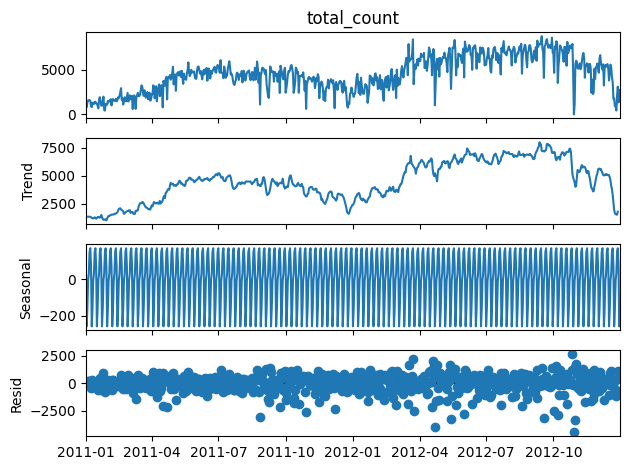

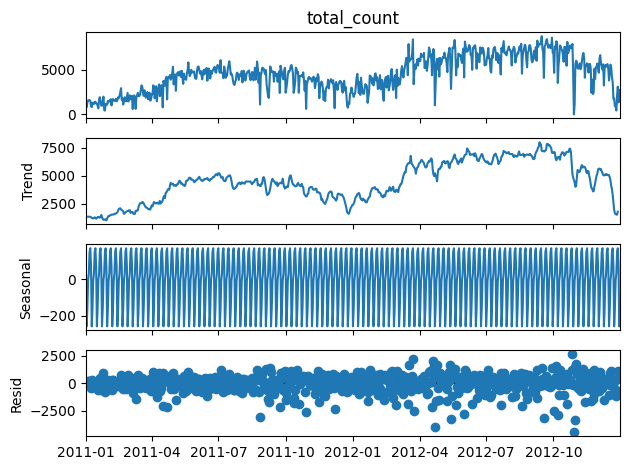

In [121]:
result = seasonal_decompose(
    ts_daily,
    model="additive",
    period=7,  # weekly seasonality
)

result.plot()

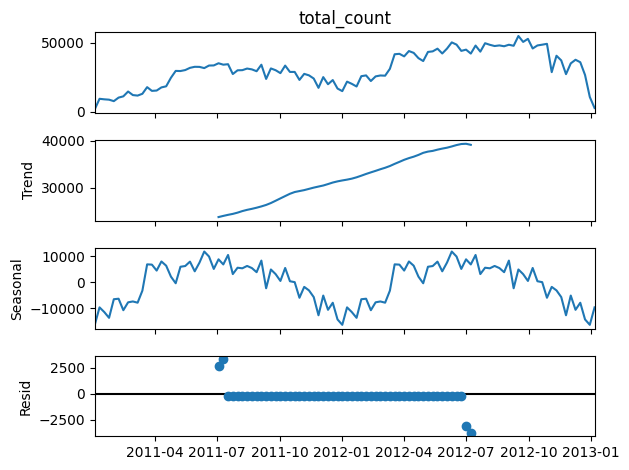

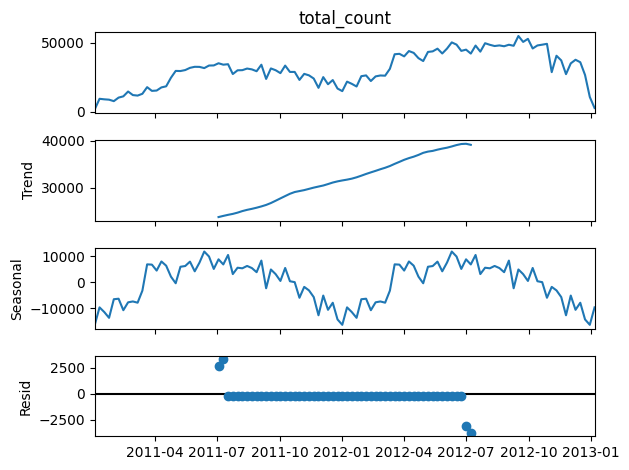

In [122]:
ts_weekly = ts.resample("W").sum()

result = seasonal_decompose(
    ts_weekly,
    model="additive",
    period=52,  # yearly seasonality in weeks
)

result.plot()